In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


In [3]:
base_dir=Path.cwd().parent
data = base_dir / "data" / "bbc_news_dataset.csv"

In [4]:
df = pd.read_csv(data)

In [5]:
df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ArticleId  1490 non-null   int64
 1   Text       1490 non-null   str  
 2   Category   1490 non-null   str  
dtypes: int64(1), str(2)
memory usage: 35.1 KB


In [7]:
df[df["ArticleId"]<10]

,ArticleId,Text,Category
233,2,worldcom boss left books alone former worldc...,business
922,4,yeading face newcastle in fa cup premiership s...,sport
1423,7,blair prepares to name poll date tony blair is...,politics


In [8]:
X = df['Text']
Y = df['Category']


In [9]:
category_names = df['Category'].unique()
print(category_names)

<StringArray>
['business', 'tech', 'politics', 'sport', 'entertainment']
Length: 5, dtype: str


In [10]:
values_count = df['Category'].value_counts()
print(values_count)

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


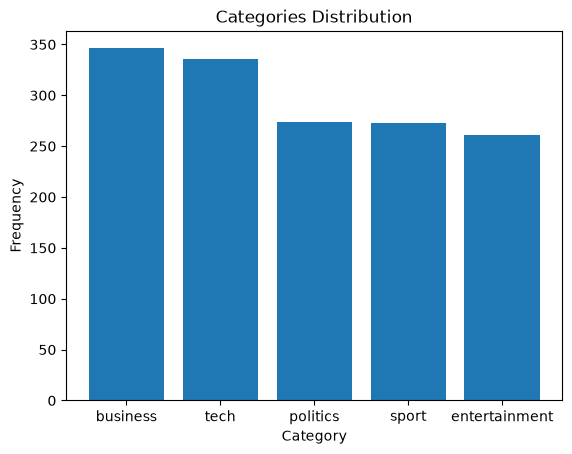

In [11]:
plt.bar(x=category_names, height=values_count)
plt.title('Categories Distribution')
plt.xlabel('Category')
plt.ylabel("Frequency")
plt.show()

In [12]:
from wordcloud import WordCloud
#The most popular and widely used library for creating word clouds in Python is wordcloud. It calculates word frequencies from raw text and maps their sizes to represent importance

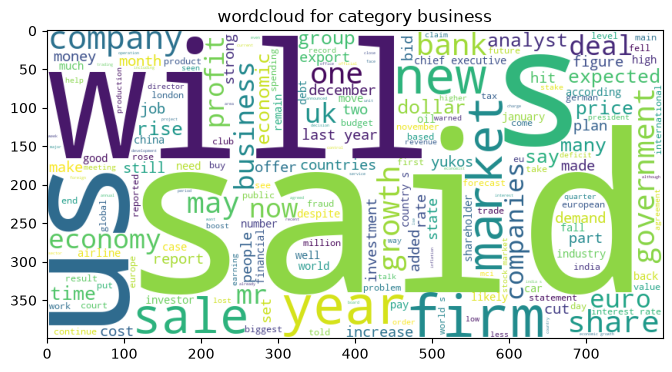

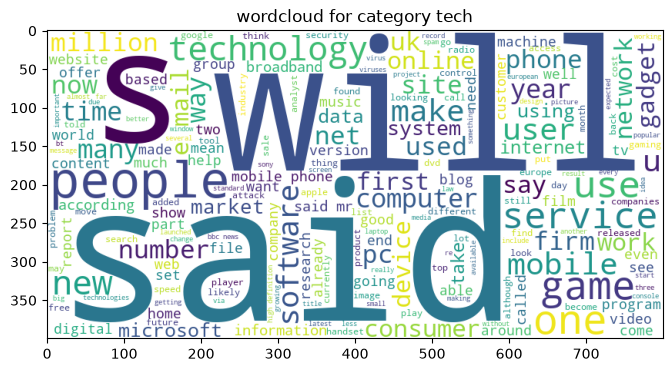

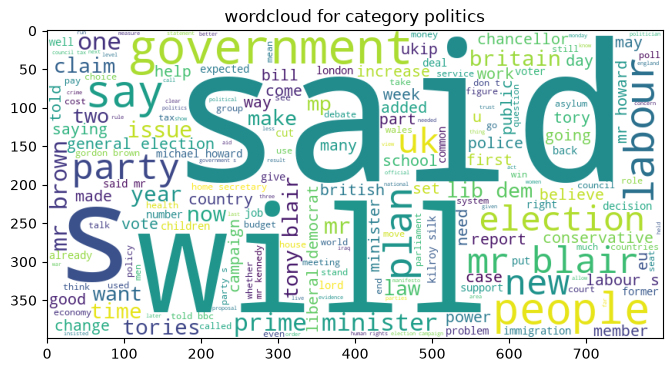

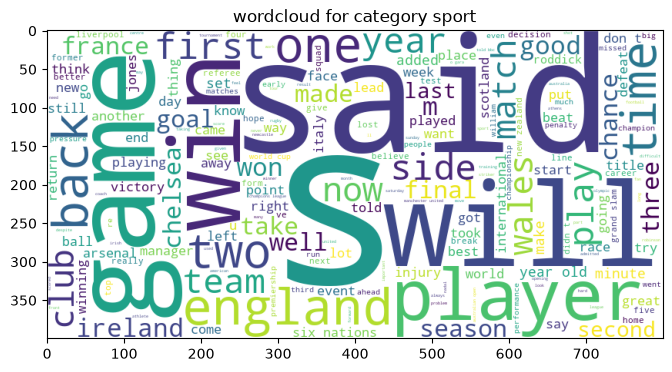

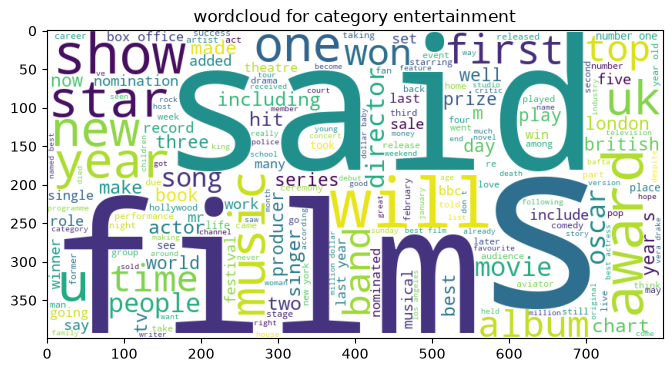

In [13]:
for category in category_names:
    text = ' '.join(df[df['Category']==category]['Text'].values)
    wc = WordCloud(width=800, height=400,
                   background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.title(f"wordcloud for category {category}")
    plt.show()

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay,accuracy_score

In [15]:
X_train, X_test, y_train ,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [16]:
model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)


In [17]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidfvectorizer', ...), ('multinomialnb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U13](5,)","['business','entertainment','politics','sport','tech']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.

In [18]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9563758389261745


In [19]:
print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



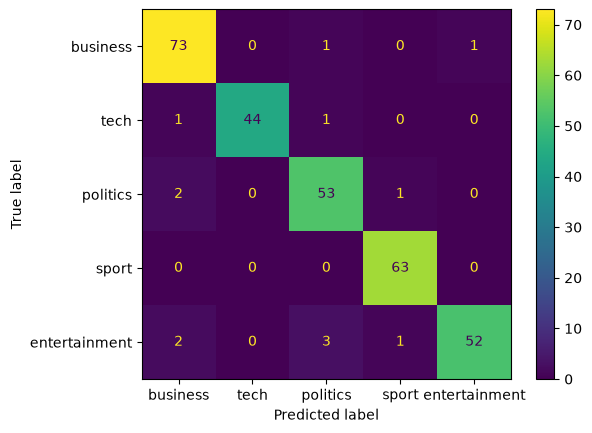

In [20]:
cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,
                       display_labels=category_names).plot()

In [21]:
texts = ['Enter any news article text here.']
prediction = model.predict(texts)
print(prediction)

['tech']


# Task 4
- Save the trained model and reload it to perform predictions on new data

In [22]:
import joblib
joblib.dump(model,'model.joblib')
print('SUCCESS')

SUCCESS


In [23]:
loaded_model = joblib.load("model.joblib")
new_article = ["The stock market crashed today as investors feared recession.",
    "Manchester United won the Premier League title last night.",
    "The government announced new tax reforms for small businesses.",
    "Scientists discovered a new planet outside our solar system.",
    "The new iPhone 16 was released with AI-powered features."]
predictions = loaded_model.predict(new_article)
print(predictions)

['business' 'sport' 'business' 'entertainment' 'tech']


# Task3
- Classify at least five custom news articles and record the predicted categories.

In [24]:
sample_text = ["""worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against
                a battery of fraud charges have called a company whistleblower as their first witness.  
               cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular 
               accounting practices at the us telecoms giant in 2002. her warnings led to the collapse
                of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has 
               pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued 
               that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees
                to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper 
                who now runs her own consulting business  told a jury in new york on wednesday that external
                auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said
                andersen had given a  green light  to the procedures and practices used by worldcom. mr ebber 
               s lawyers have said he was unaware of the fraud  arguing that auditors did not alert him to any problems. 
                ms cooper also said that during shareholder meetings mr ebbers often passed over technical questions
                to the company s finance chief  giving only  brief  answers himself. the prosecution s star witness 
                former worldcom financial chief scott sullivan  has said that mr ebbers ordered accounting adjustments
                at the firm  telling him to  hit our books . however  ms cooper said mr sullivan had not mentioned 
                anything uncomfortable  about worldcom s accounting during a 2001 audit committee meeting. mr 
               ebbers could face a jail sentence of 85 years if convicted of all the charges he is facing. worldcom 
               emerged from bankruptcy protection in 2004  and is now known as mci.
                last week  mci agreed to a buyout by verizon communications in a deal valued at $6.75bn."""]
prediction= model.predict(sample_text)
print(prediction)

['business']


In [25]:
sample_text=["german business confidence slides german business confidence fell"
" in february knocking hopes of a speedy recovery in europe s largest economy."
"  munich-based research institute ifo said that its confidence index fell to "
"95.5 in february from 97.5 in january  its first decline in three months. the study "
"found that the outlook in both the manufacturing and retail sectors had worsened. "
"observers had been hoping that a more confident business sector would signal that economic activity was picking up. "
"  we re surprised that the ifo index has taken such a knock   said dz bank economist bernd weidensteiner.  "
"the main reason is probably that the domestic economy is still weak  particularly in the retail trade."
"  economy and labour minister wolfgang clement called the dip in february s ifo confidence figure  a very mild decline ."
" he said that despite the retreat  the index remained at a relatively high level and that he expected"
"  a modest economic upswing  to continue.  germany s economy grew 1.6% last year after shrinking in 2003."
" however  the economy contracted by 0.2% during the last three months of 2004  mainly due to the reluctance of "
"consumers to spend. latest indications are that growth is still proving elusive and ifo president hans-werner"
" sinn said any improvement in german domestic demand was sluggish. exports had kept things going during the "
"first half of 2004  but demand for exports was then hit as the value of the euro hit record levels making"
" german products less competitive overseas. on top of that  the unemployment rate has been stuck at close"
" to 10% and manufacturing firms  including daimlerchrysler  siemens and volkswagen  have been negotiating with unions over cost cutting measures. analysts said that the ifo figures and germany s continuing problems may delay an interest rate rise by the european central bank. eurozone interest rates are at 2%  but comments from senior officials have recently focused on the threat of inflation  prompting fears that interest rates may rise."]
prediction= model.predict(sample_text)
print(prediction)

['business']


In [26]:
sample_text=["lifestyle  governs mobile choice  faster  better or funkier hardware alone is not going to help phone firms sell more handsets  research suggests.  instead  phone firms keen to get more out of their customers should not just be pushing the technology for its own sake. consumers are far more interested in how handsets fit in with their lifestyle than they are in screen size  onboard memory or the chip inside  shows an in-depth study by handset maker ericsson.  historically in the industry there has been too much focus on using technology   said dr michael bjorn  senior advisor on mobile media at ericsson s consumer and enterprise lab.  we have to stop saying that these technologies will change their lives   he said.  we should try to speak to consumers in their own language and help them see how it fits in with what they are doing   he told the bbc news website.  for the study  ericsson interviewed 14 000 mobile phone owners on the ways they use their phone.  people s habits remain the same   said dr bjorn.  they just move the activity into the mobile phone as it s a much more convenient way to do it.   one good example of this was diary-writing among younger people  he said. while diaries have always been popular  a mobile phone -- especially one equipped with a camera -- helps them keep it in a different form. youngsters  use of text messages also reflects their desire to chat and keep in contact with friends and again just lets them do it in a slightly changed way. dr bjorn said that although consumers do what they always did but use a phone to do it  the sheer variety of what the new handset technologies make possible does gradually drive new habits and lifestyles. ericsson s research has shown that consumers divide into different  tribes  that use phones in different ways. dr bjorn said groups dubbed  pioneers  and  materialists  were most interested in trying new things and were behind the start of many trends in phone use.  for instance   he said   older people are using sms much more than they did five years ago.  this was because younger users  often the children of ageing mobile owners  encouraged older people to try it so they could keep in touch.  another factor governing the speed of change in mobile phone use was the simple speed with which new devices are bought by pioneers and materialists. only when about 25% of people have handsets with new innovations on them  such as cameras  can consumers stop worrying that if they send a picture message the person at the other end will be able to see it.  once this significant number of users is passed  use of new innovations tends to take off. dr bjorn said that early reports of camera phone usage in japan seemed to imply that the innovation was going to be a flop. however  he said  now 45% of the japanese people ericsson questioned use their camera phone at least once a month. in 2003 the figure was 29%. similarly  across europe the numbers of people taking snaps with cameras is starting to rise. in 2003 only 4% of the people in the uk took a phonecam snap at least once a month. now the figure is 14%. similar rises have been seen in many other european nations. dr bjorn said that people also used their camera phones in very different ways to film and even digital cameras.  usage patterns for digital cameras are almost exactly replacing usage patterns for analogue cameras   he said. digital cameras tend to be used on significant events such as weddings  holidays and birthdays. by contrast  he said  camera phones were being used much more to capture a moment and were being woven into everyday life."]
prediction= model.predict(sample_text)
print(prediction)

['tech']


In [27]:
sample_text = ["carry on star patsy rowlands dies actress patsy rowlands  known to millions for her roles in the carry on films  has died at the age of 71.  rowlands starred in nine of the popular carry on films  alongside fellow regulars sid james  kenneth williams and barbara windsor. she also carved out a successful television career  appearing for many years in itv s well-loved comedy bless this house. rowlands died in hove on saturday morning  her agent said.  born in january 1934  rowlands won a scholarship to the guildhall school of speech and drama scholarship when she was just 15.  after spending several years at the players theatre in london  she made her film debut in 1963 in tom jones  directed by tony richardson. she made her first carry on film in 1969 where she appeared in carry on again doctor. rowlands played the hard-done-by wife or the put-upon employee as a regular carry on star. she also appeared in carry on at your convenience  carry on matron and carry on loving  as well as others.  in recent years she appeared in bbc mini-series the cazalets and played mrs potts in the london stage version of beauty and the beast. agent simon beresford said:  she was just an absolutely favourite client she never complained about anything  particularly when she was ill  she was an old trouper.  she was of the old school - she had skills from musical theatre and high drama  that is why she worked with the great and the good of directors.  she didn t mind always being recognised for the carry on films because she thoroughly enjoyed making them. she was a really lovely person and she will be much missed.  her last appearance on stage was as mrs pearce in the award-winning production of my fair lady at the national theatre. previously married  she leaves one son  alan. her funeral will be a private  family occasion  with a memorial service at a later date."]
prediction= model.predict(sample_text)
print(prediction)

['entertainment']


In [28]:
sample_text = ["hewitt overcomes wobble in sydney lleyton hewitt gave himself the perfect preparation for next week s australian open with victory over ivo minar in the final of the sydney international.  the defending champion brushed aside the czech qualifier 7-5 6-0. the australian world number three strolled to the first five games of the match but was shocked as minar won the next five. the top seed was rattled but recovered to close out the set and raced to victory in exactly an hour.  it was a strange match . . . momentum swings   said hewitt.  i felt like i came out of the blocks extremely well  but then he loosened up a bit.  when he got back to 5-5  i had to try to settle down and take it up a notch  and i was able to do that.   hewitt has now lifted the sydney title four times in the last six years.  it just keeps getting better and better every year   hewitt said.  i ve only played this tournament four times and i ve won it four times.  hewitt went into the final as a short-priced favourite to clinch his 24th career title after dropping only one set all week. he is set to meet frenchman arnaud clement in the first round of the australian open. minar  ranked 158th in the world  was forced to pull out of the australian open qualifying draw to play in his first atp final.  for me  this was a big success   said the 20-year-old.  i was so nervous last night i couldn t sleep. i ve never played a top-10 player before.  i wanted to play qualifying in melbourne  but it s saturday and i m still here. but this is a main draw and i need the points and the money.  alicia molik takes on samantha stosur in an all-australian women s final later on saturday."]
prediction= model.predict(sample_text)
print(prediction)

['sport']


In [29]:
sample_text = ["uk will stand firm on eu rebate  britain s Â£3bn eu rebate is not up for renegotiation at next week s european council summit  jack straw said.  the foreign secretary told mps the rebate  secured by margaret thatcher in 1984  was  entirely justified . new european commission president jose manuel barroso has suggested the cash could be shared out among net contributors to the eu budget. mr straw acknowledged some countries in the newly enlarged 25 nation eu still had to  see the light  on the rebate.  but the foreign secretary told the commons foreign affairs committee:  our position is very clear: it is entirely justified and it is not for negotiation.  he added that he did not think there would be a political price to pay for the uk s stance - britain contributed more and received less than other eu states. the two-day european council summit in brussels begins on 16 december and is widely expected to mark the beginning of a lengthy negotiating period over the eu s budget for 2007-13. the wrangling could stretch into 2005  even 2006.  the uk  france  germany  austria  the netherlands and sweden want the eu budget to be capped at 1% of member states  combined national incomes - the commission wants it to be 1.26%. mr straw said the eu commission s proposal would mean a 35% hike in the budget.  i don t know of any national government thinking of increasing its budget by that amount   he added. the foreign secretary said he hoped the talks next week could produce a date in 2005 for the beginning of negotiations with turkey about possible eu membership although that there would be no prospect of a date for joining for some time."]
prediction= model.predict(sample_text)
print(prediction)

['politics']


**Task 5 and Task 6**
- Experiment with train test split ratio
- Evaluate the model using train test splits:

            70% – 30%
            80% – 20%
            90% – 10%

In [30]:
splits = [0.3,0.2,0.1]
results=[]
for test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=test_size,random_state=42)
    m = make_pipeline(TfidfVectorizer(stop_words='english'),MultinomialNB())
    m.fit(X_train,y_train)
    acc= accuracy_score(y_test, m.predict(X_test))
    results.append({'Split':f"{int((1-test_size)*100)}/{int(test_size*100)}",'Accuracy':round(acc , 4)})
results_df=pd.DataFrame(results)
print(results_df)

   Split  Accuracy
0  70/30    0.9687
1  80/20    0.9564
2  90/10    0.9597


## Task 2
- Experiment with TF-IDF parameters such as max_features, ngram_range, and min_df.

In [31]:
experiments = [
    {"max_features": None, "ngram_range": (1,1), "min_df": 1},
    {"max_features": 5000, "ngram_range": (1,1), "min_df": 1},
    {"max_features": 5000, "ngram_range": (1,2), "min_df": 1},
    {"max_features": 5000, "ngram_range": (1,2), "min_df": 2},
    {"max_features": 10000,"ngram_range": (1,2), "min_df": 2},
]
results = []

In [32]:
for params in experiments:
    m = make_pipeline(
        TfidfVectorizer(
            stop_words='english',
            max_features=params['max_features'],
            ngram_range=params['ngram_range'],
            min_df=params['min_df']
        ),
        MultinomialNB()
    )
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    results.append({
        'max_features': params['max_features'],
        'ngram_range' : params['ngram_range'],
        'min_df'      : params['min_df'],
        'Accuracy'    : round(acc, 4)
    })


In [33]:
results_df = pd.DataFrame(results)
print(results_df)

   max_features ngram_range  min_df  Accuracy
0           NaN      (1, 1)       1    0.9597
1        5000.0      (1, 1)       1    0.9732
2        5000.0      (1, 2)       1    0.9866
3        5000.0      (1, 2)       2    0.9866
4       10000.0      (1, 2)       2    0.9664


# TASK 7
*Perform 5-Fold Cross Validation and calculate Mean Accuracy and Standard Deviation*
```
The problem with single train test split
- when you do 80/20 split , your accuracy depends on which 20 % happened to be the test-set
 you might get lucky or unlucky with particular split.
```
```
Cross validation fixes this , it test the model 5 times on different portions:
like test can be in first 20 percent of the data , or it can be between 20 - 40 percent similary for other 3.
mean <- much more reliable than single split
```


In [34]:
from sklearn.model_selection import cross_val_score
#5 flod cross validation
pipeline = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)
scores = cross_val_score(pipeline, X, Y, cv = 5, scoring='accuracy')
print("5 fold cross validation Results")
print(f"Fold scores: {[round(s,4) for s in scores]}")
print(f"Mean Accuracy  : {scores.mean():.4f}")
print(f"Std Deviation  : {scores.std():.4f}")

5 fold cross validation Results
Fold scores: [np.float64(0.9631), np.float64(0.953), np.float64(0.9698), np.float64(0.9799), np.float64(0.9664)]
Mean Accuracy  : 0.9664
Std Deviation  : 0.0088


# Task 8
- Discuss whether the model is stable across different folds.
- Stability = how consistent the model is across different folds, measured by standard deviation.

```
An unstable model means it's sensitive to which data it sees — it might perform great on some users and poorly on others in production. A stable model is predictable and trustworthy.
```

Stablity Analysis
Model is Very stable - low variance across fold


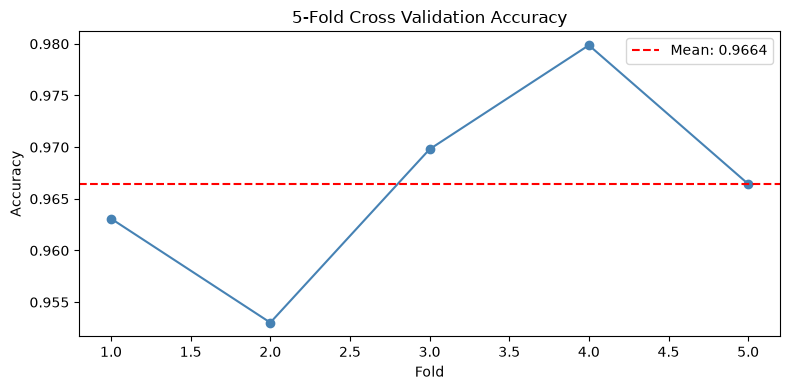

In [36]:
print("Stablity Analysis")
if scores.std() < 0.01:
    print("Model is Very stable - low variance across fold")
elif scores.std() < 0.03:
    print("Model is Stable- minor variance across folds")
else:
    print("Model is unstable - high variance across folds")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), scores, marker='o', color='steelblue')
plt.axhline(scores.mean(), color='red', linestyle='--', label=f'Mean: {scores.mean():.4f}')
plt.title('5-Fold Cross Validation Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
